In [ ]:
# For the data processing and maths
import matplotlib.pyplot as matplot
import numpy as np
import pandas as pd
import seaborn
import missingno as misnum

# For the Chi-squared tests
from scipy import stats
from scipy.stats import chi2_contingency # This is for the various statistical tests

# For the imputation
from sklearn.experimental import enable_iterative_imputer # For imputing the 'age' data
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer # For imputing the 'embarked' data
from sklearn import preprocessing # For standardising data

# For the Apriori algorithm
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# For the CatBoost algorithm
from catboost import CatBoostRegressor
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# For linear regression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score

# For decision tree
from sklearn.metrics import classification_report as cr
from sklearn.metrics import confusion_matrix as cm
from sklearn.tree import DecisionTreeClassifier


trainingData = pd.read_csv('../input/traindataset/train.csv')


In [2]:
#----START OF PRE-PROCESSING

In [3]:
# Check to see if there are any null data
null_columns=trainingData.columns[trainingData.isnull().any()]
print("All missing data")
print(trainingData[null_columns].isnull().sum())

# PassengerId
print("Missing PassengerId")
print(trainingData[trainingData["PassengerId"].isnull()][null_columns])

# Pclass
print("Missing Pclass")
print(trainingData[trainingData["Pclass"].isnull()][null_columns])

# Name
print("Missing Name")
print(trainingData[trainingData["Name"].isnull()][null_columns])

# Sex
print("Missing Sex")
print(trainingData[trainingData["Sex"].isnull()][null_columns])

# Age
print("Missing Age")
print(trainingData[trainingData["Age"].isnull()][null_columns])

# SibSp
print("Missing SibSp")
print(trainingData[trainingData["SibSp"].isnull()][null_columns])

# Parch
print("Missing Parch")
print(trainingData[trainingData["Parch"].isnull()][null_columns])

# Ticket
print("Missing Ticket")
print(trainingData[trainingData["Ticket"].isnull()][null_columns])

# Fare
print("Missing Fare")
print(trainingData[trainingData["Fare"].isnull()][null_columns])

# Cabin
print("Missing Cabin")
print(trainingData[trainingData["Cabin"].isnull()][null_columns])

# Embarked
print("Missing Embarked")
print(trainingData[trainingData["Embarked"].isnull()][null_columns])

# Name
print("Missing Names")
print(trainingData[trainingData["Name"].isnull()][null_columns])

All missing data
Age         177
Cabin       687
Embarked      2
dtype: int64
Missing PassengerId
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Pclass
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Name
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Sex
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Age
     Age Cabin Embarked
5    NaN   NaN        Q
17   NaN   NaN        S
19   NaN   NaN        C
26   NaN   NaN        C
28   NaN   NaN        Q
..   ...   ...      ...
859  NaN   NaN        C
863  NaN   NaN        S
868  NaN   NaN        S
878  NaN   NaN        S
888  NaN   NaN        S

[177 rows x 3 columns]
Missing SibSp
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Parch
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Ticket
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Fare
Empty DataFrame
Columns: [Age, Cabin, Embarked]
Index: []
Missing Cabin
    

<AxesSubplot:>

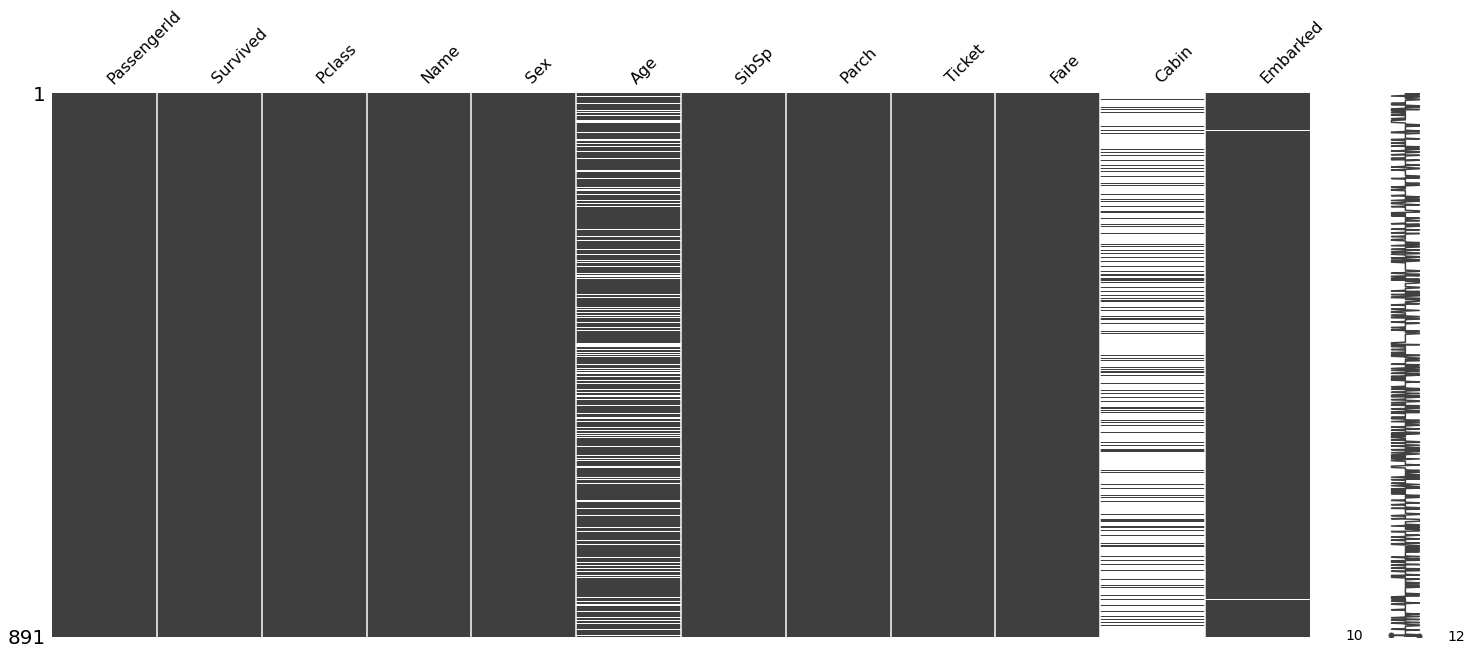

In [4]:
# Visualise all of the missing data using the missingno Python library
misnum.matrix(trainingData)

<AxesSubplot:>

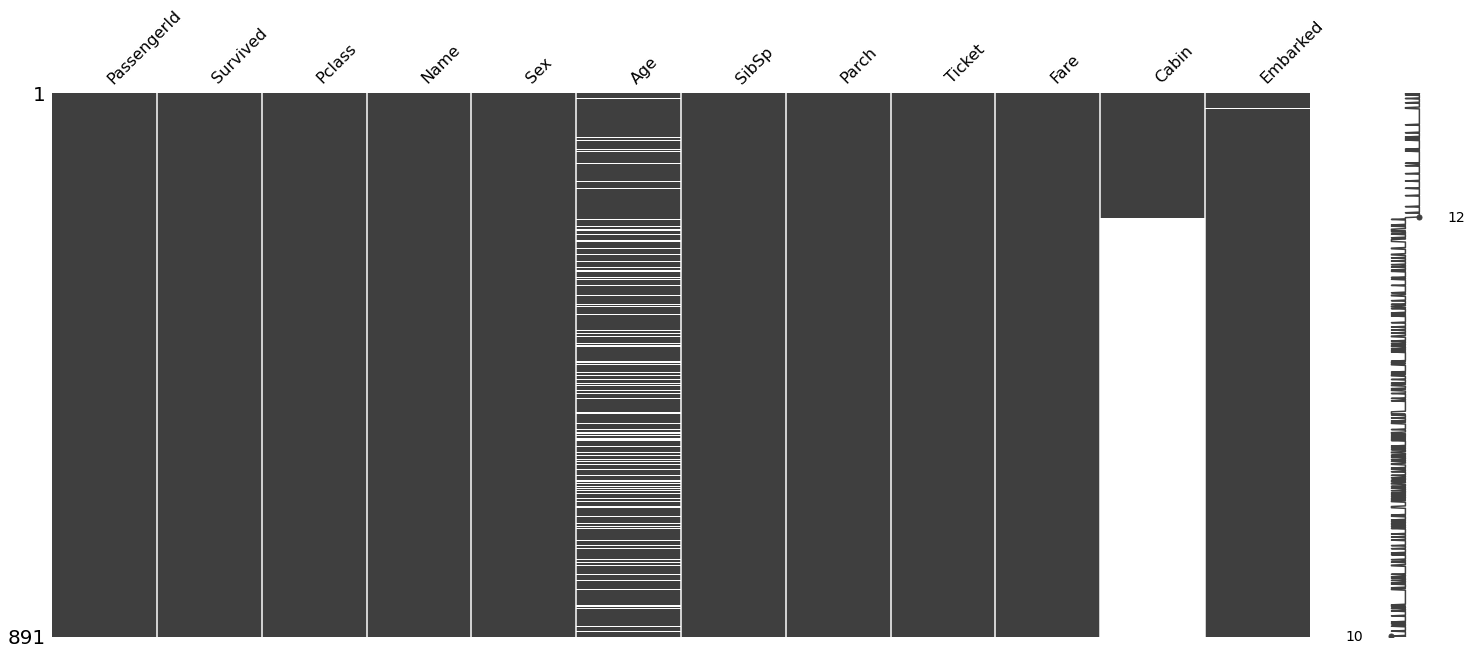

In [5]:
# Sort the above visualisation by Cabin
misnum.matrix(trainingData.sort_values('Cabin'))

<AxesSubplot:>

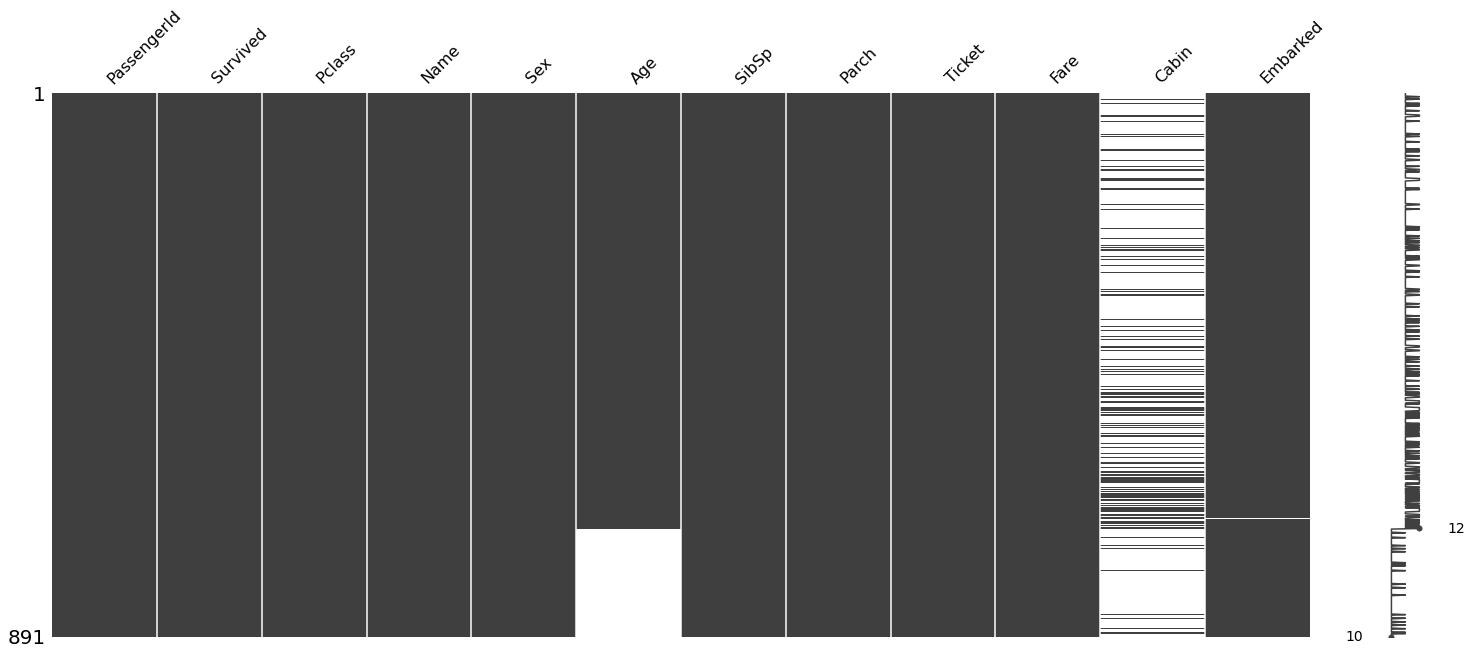

In [6]:
# Sort the above visualisation by Age
misnum.matrix(trainingData.sort_values('Age'))

<AxesSubplot:>

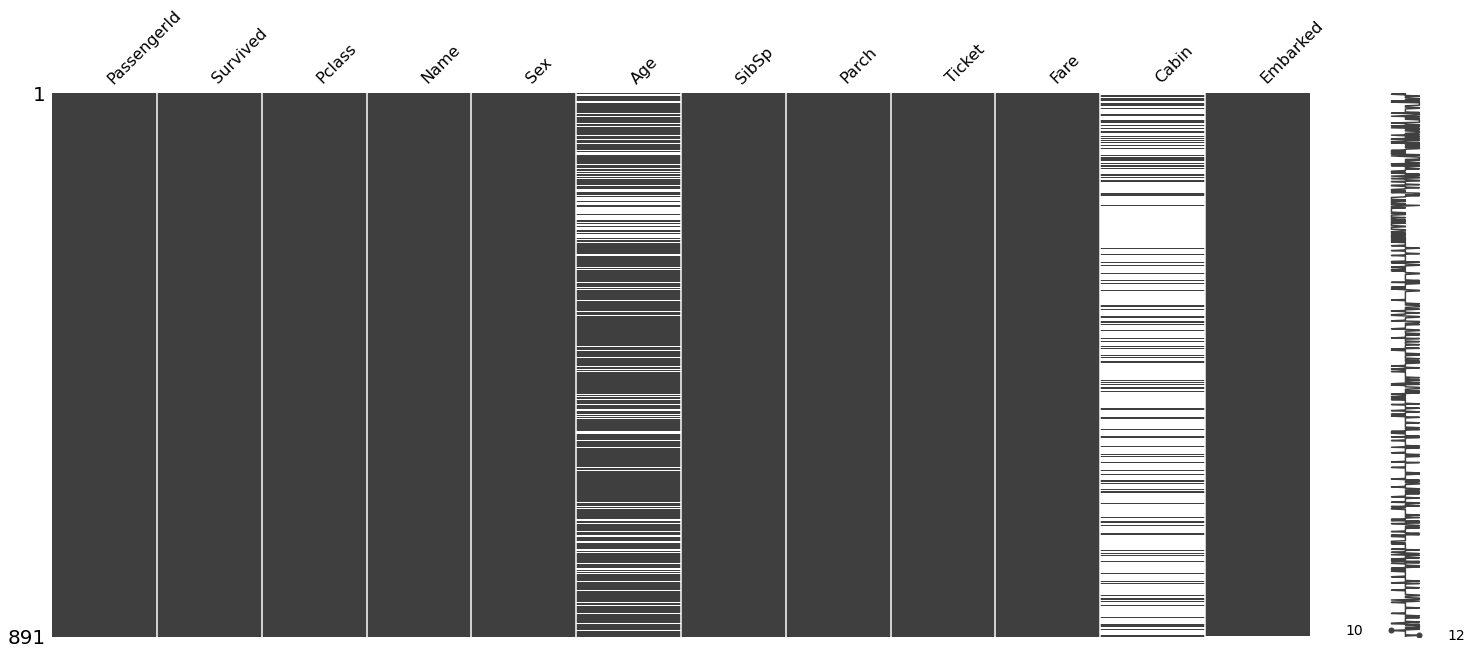

In [7]:
# Sort the above visualisation by Embarked
misnum.matrix(trainingData.sort_values('Embarked'))

In [8]:
# Check to see if there are any 'unit non-responses' (entire rows that are empty)
trainingData[trainingData.isna().all(axis=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [9]:
# Create a categorical version of the numeric data columns
# Catagorise the age data into a 'cat_age' column
trainingData['cat_age'] = trainingData['Age']
trainingData['cat_age'] = pd.cut(trainingData['cat_age'], bins = [0,14,64,150], include_lowest = True, right = True, labels=['Low','Middle','High'])

In [10]:
# Categorise the 'SibSp' data into a 'cat_SibSp' column
trainingData['cat_SibSp'] = trainingData['SibSp']
trainingData['cat_SibSp'] = pd.cut(trainingData['cat_SibSp'], bins = [0,2,5,8], include_lowest = True, right = True, labels=['Low','Middle','High'])

In [11]:
# Categorise the 'Parch' data into a 'cat_Parch' column
trainingData['cat_Parch'] = trainingData['Parch']
# Convert the column to an array for searching
trainingData['cat_Parch'] = pd.cut(trainingData['cat_Parch'], bins = [0,2,4,6], include_lowest = True, right = True, labels=['Low','Middle','High'])

In [12]:
# Categorise 'ticket' into 'with letters' and 'without letters'
trainingData['cat_Ticket'] =  trainingData['Ticket']
has_letter = []
no_letter = []
letter_ordinal_list = []
only_number_ordinal_list = []
cat_list = []
# Iterate through the array and check if it contains a letter
for item in trainingData['Ticket'].iteritems():
    string = str(item)
    if any(a.isalpha() for a in string):
        # Add to the list of the added item's place in the dataset
        formatted_text = string.partition(",")[0]
        formatted_ticket = string.partition(",")[2]
        has_letter.append(formatted_ticket)
        category = 'letter'
        cat_list.append(category)
        final_formtatted_text = formatted_text[1:]
        letter_ordinal_list.append(final_formtatted_text)
    else:
        # Add to the list of the added item's place in the dataset
        number_formatted_text = string.partition(",")[0]
        formatted_number_ticket = string.partition(",")[2]
        no_letter.append(formatted_ticket)
        category = 'noLetter'
        cat_list.append(category)
        number_final_formtatted_text = number_formatted_text[1:]
        only_number_ordinal_list.append(number_final_formtatted_text)
# Convert the ordinal arrays into integer arrays
# I got the conversion code off https://stackoverflow.com/questions/56772170/convert-string-array-into-integer-python
letter_ordinal_list = [int(i, base=10) for i in letter_ordinal_list]
only_number_ordinal_list = [int(i, base=10) for i in only_number_ordinal_list]
# Add the ticket categories to 'cat_ticket' in the dataframe
len_has_letter = len(letter_ordinal_list)
len_no_letter = len(only_number_ordinal_list)
trainingData['cat_ticket'] = cat_list

In [13]:
# Categorise the 'fare' data into a 'cat_fare' column
highestFare= 512.3292
lowestFare = 0
trainingData['cat_fare'] = trainingData['Fare']
ticket_array = trainingData['Fare'].values
# Round the ticket values so it can be binned by Panda
rounded_ticket = [round(a) for a in ticket_array]
trainingData['cat_fare'] = rounded_ticket
# Convert the column to an array for searching
trainingData['cat_fare'] = pd.cut(trainingData['cat_fare'], bins = [0,100,200,300,400,500,600], include_lowest = True, labels=['0-99','100-199','200-299','300-399','400-499','500-599'])

0.0024685413215161066

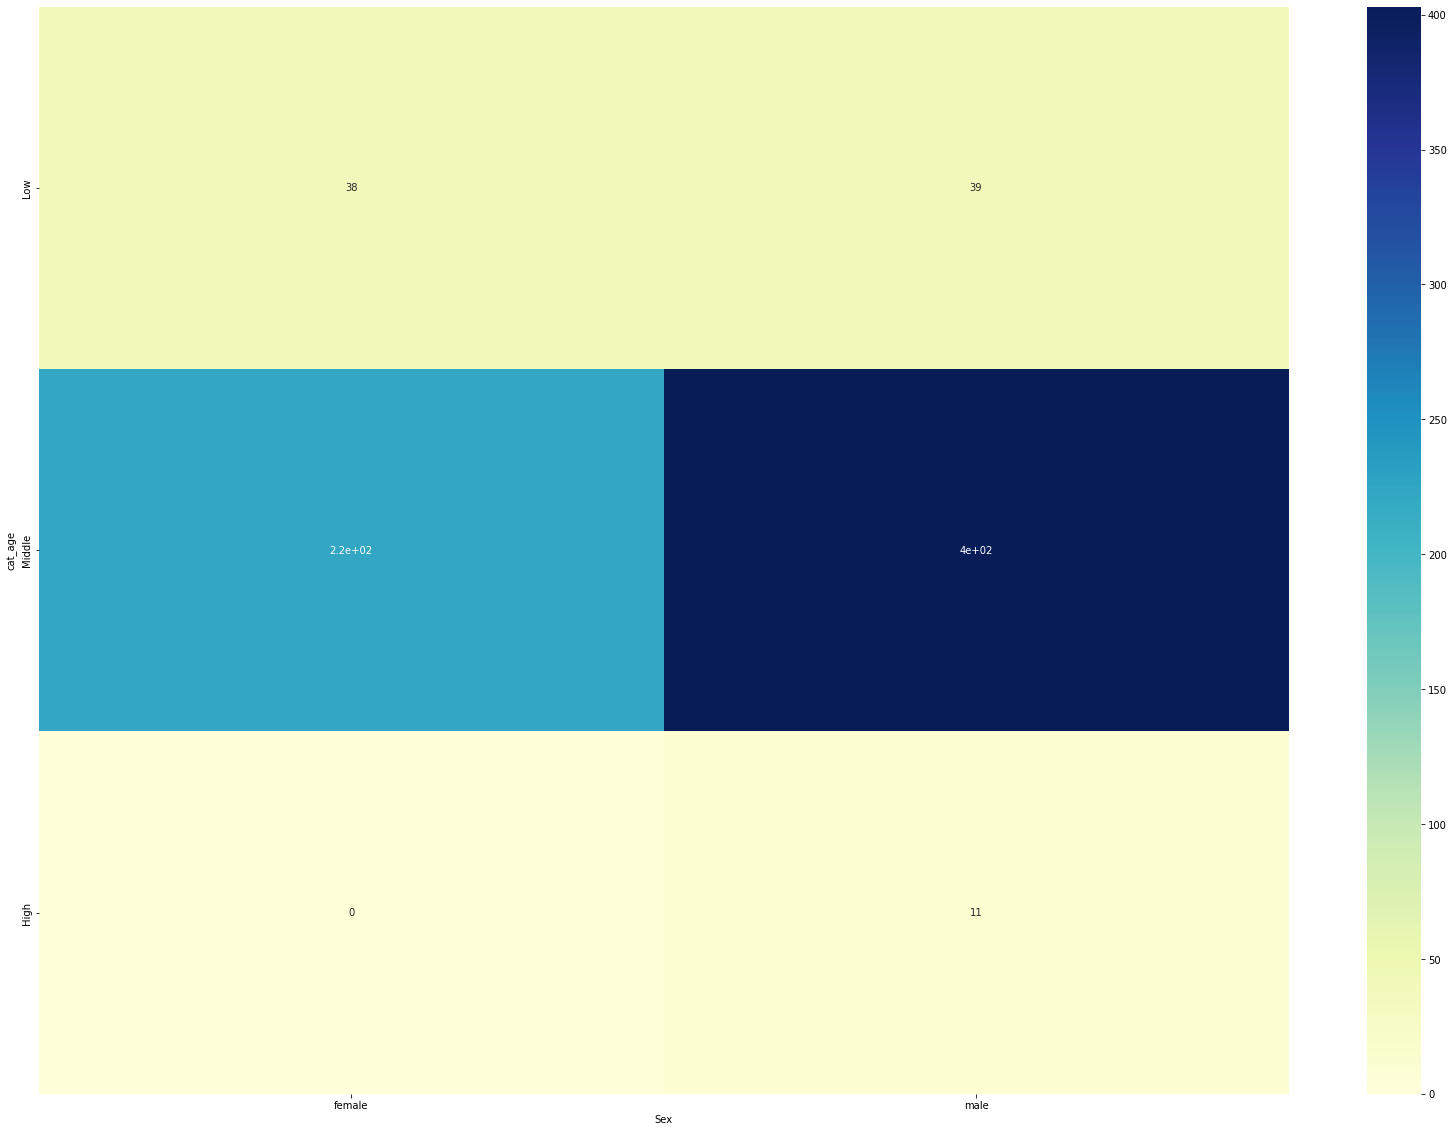

In [14]:
# Perform Chi-squared tests of independance on the Age data to check whether it is dependent on other quantitative data
# Run at a 95% confidence level
# The null hypothesis is that Age and the tested against variable are independent

# Age to sex
# --- Contingency table
ageToSexContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['Sex'])
# ageToSexContigencyTable
# # --- Contingency table with percentages
# ageToSexContigencyTablePercentage = pd.crosstab(trainingData['Age'],trainingData['Sex'], normalize='index')
# ageToSexContigencyTablePercentage
# --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToSexContigencyTable, annot=True, cmap="YlGnBu")
# --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToSexContigencyTable)
p

2.597474568852493e-37

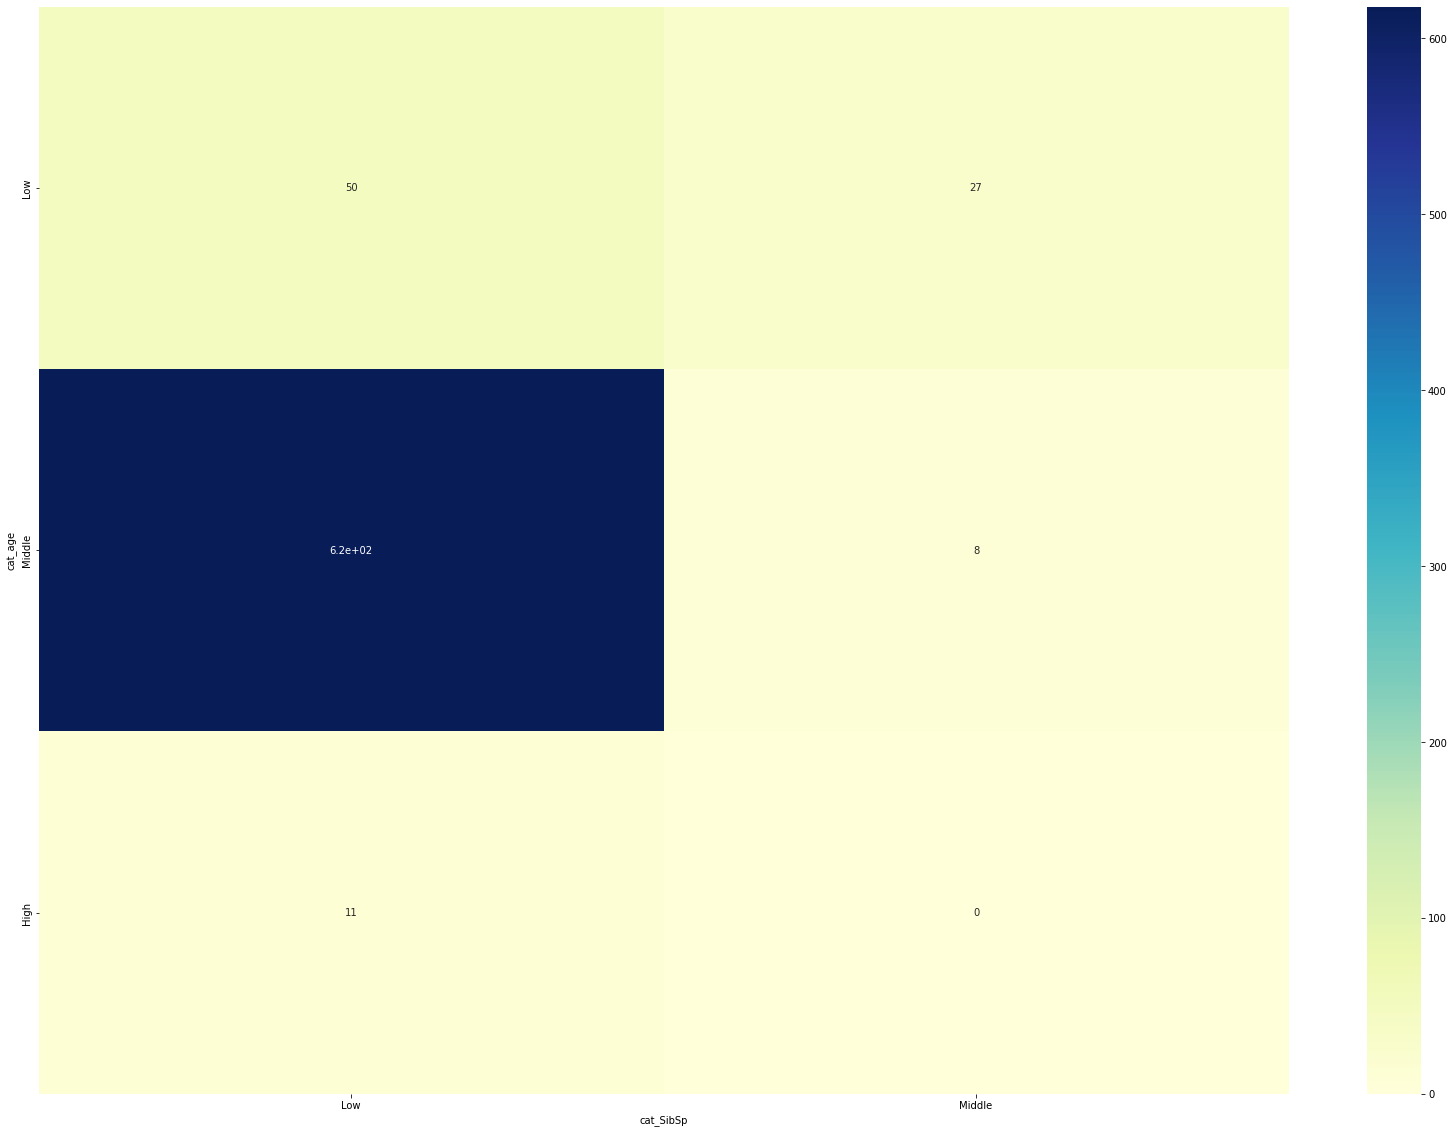

In [15]:
# Age to SibSp
# --- Contingency table
ageToSibSpContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['cat_SibSp'])
# ageToSibSpContigencyTable
# --- Contingency table with percentages
ageToSibSpContigencyTablePercentage = pd.crosstab(trainingData['Age'],trainingData['SibSp'], normalize='index')
ageToSibSpContigencyTablePercentage
# --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToSibSpContigencyTable, annot=True, cmap="YlGnBu")
# # --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToSibSpContigencyTable)
p


0.7074819053773891

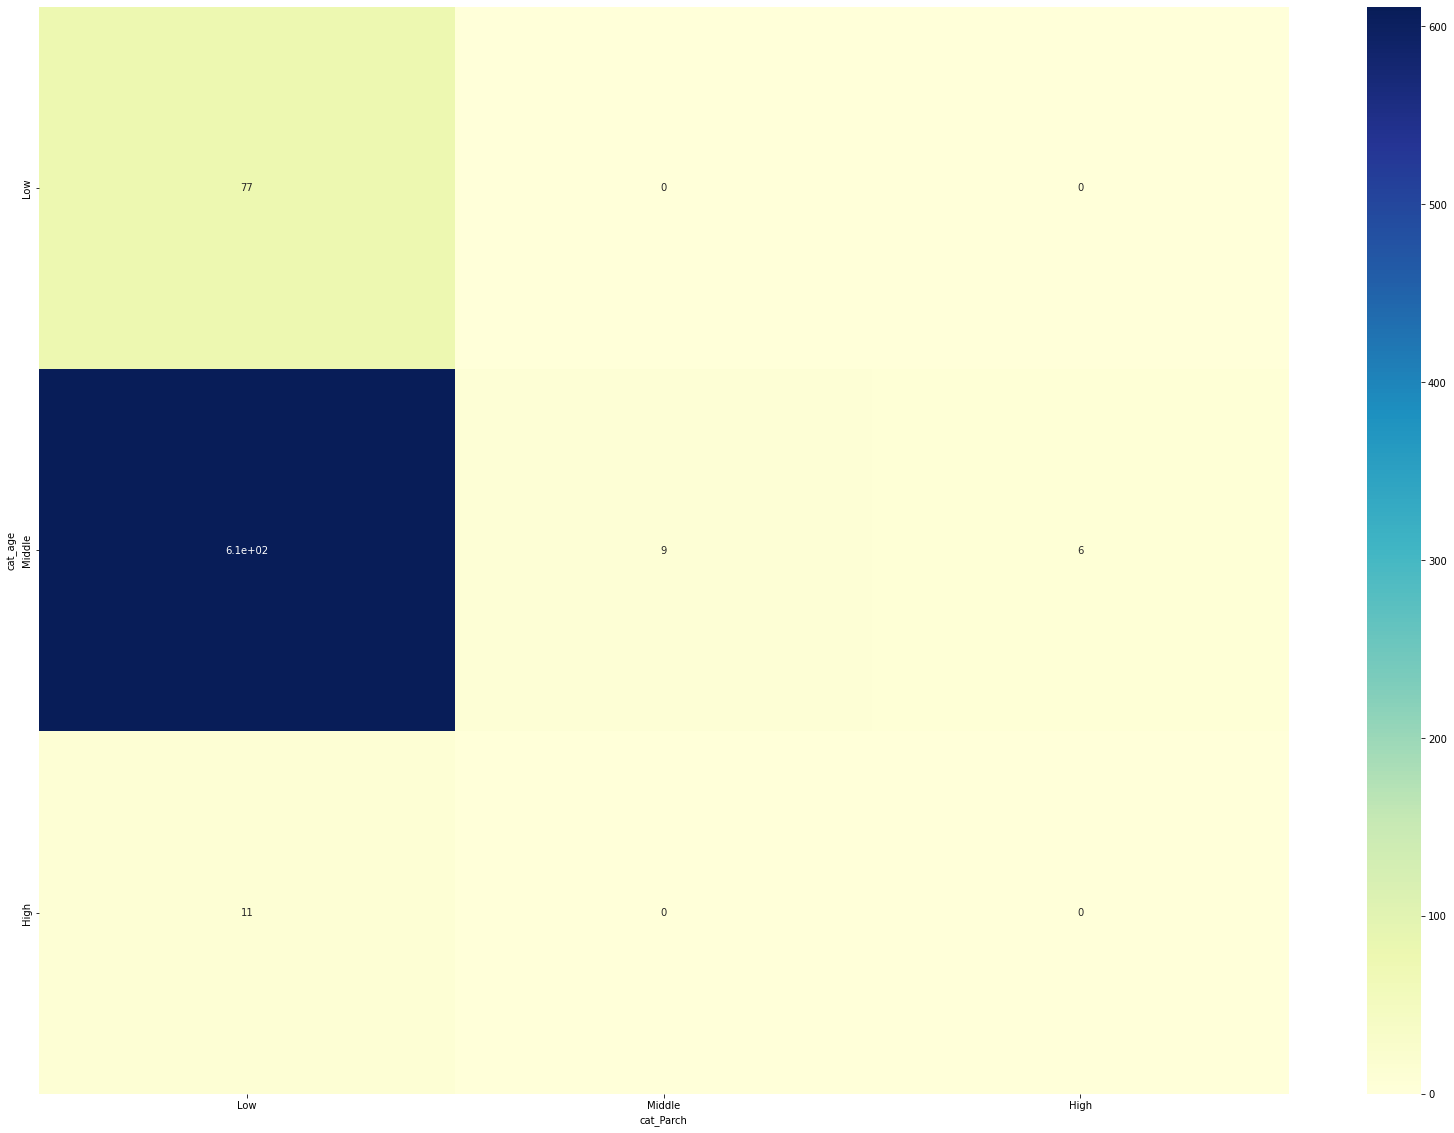

In [16]:
# Age to Parch
# --- Contingency table
ageToParchContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['cat_Parch'])
# ageToSexContigencyTable
# --- Contingency table with percentages
# ageToParchContigencyTablePercentage = pd.crosstab(trainingData['Age'],trainingData['Parch'], normalize='index')
# ageToParchContigencyTablePercentage
# --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToParchContigencyTable, annot=True, cmap="YlGnBu")
# --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToParchContigencyTable)
p

0.12035550962724571

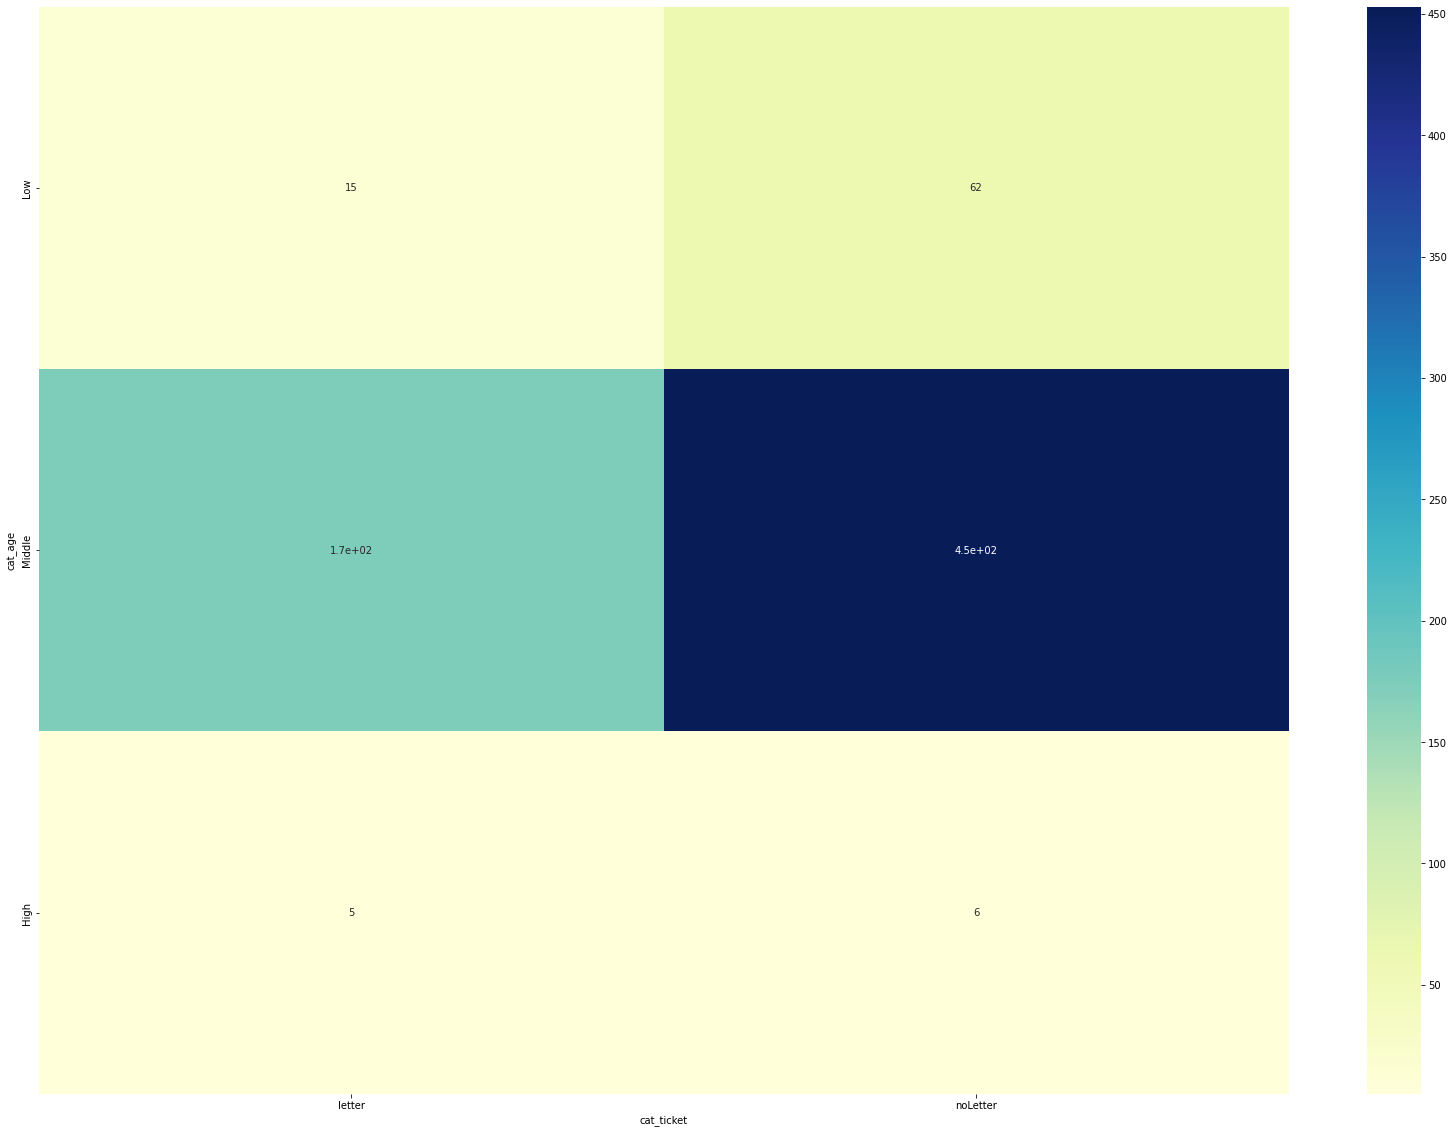

In [17]:
# Age to Ticket
# --- Contingency table
ageToTicketContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['cat_ticket'])
# ageToSexContigencyTable
# --- Contingency table with percentages
# ageToTicketContigencyTablePercentage = pd.crosstab(trainingData['Age'],trainingData['Ticket'], normalize='index')
# ageToTicketContigencyTablePercentage
# --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToTicketContigencyTable, annot=True, cmap="YlGnBu")
# # --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToTicketContigencyTable)
p

0.7761474570225351

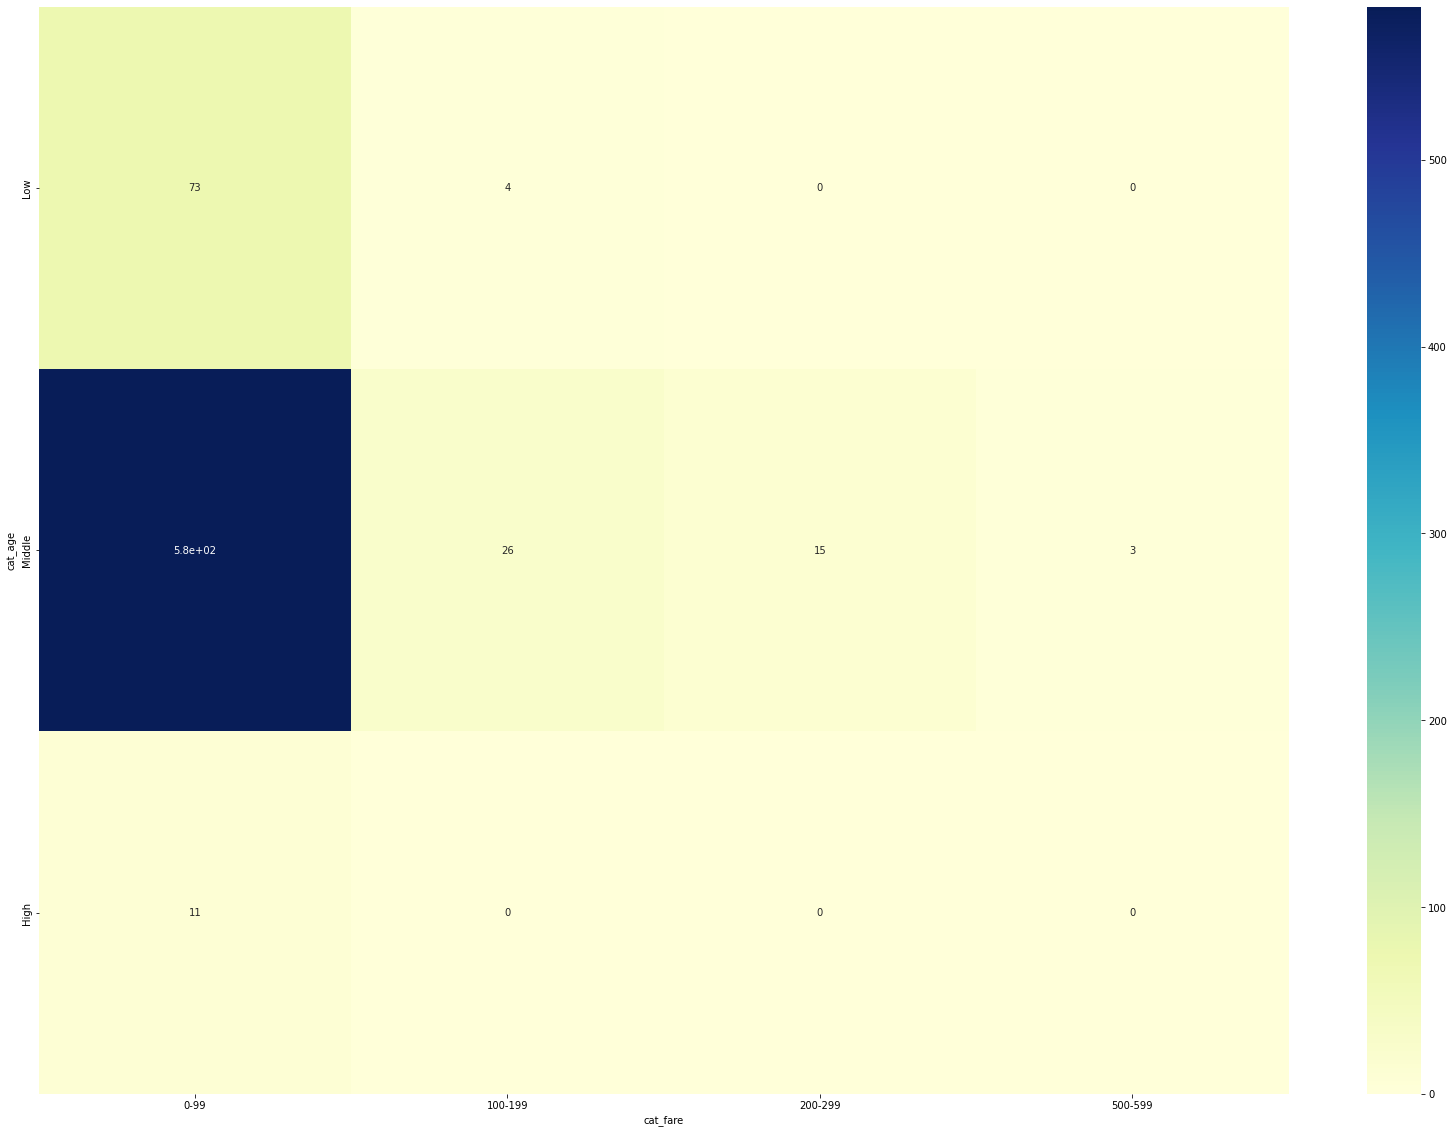

In [18]:
# Age to Fare
# --- Contingency table
ageToFareContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['cat_fare'])
# ageToSexContigencyTable
# --- Contingency table with percentages
# ageToFareContigencyTablePercentage = pd.crosstab(trainingData['cat_age'],trainingData['cat_fare'], normalize='index')
# ageToFareContigencyTablePercentage
# # --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToFareContigencyTable, annot=True, cmap="YlGnBu")
# --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToFareContigencyTable)
p

0.00012478937929448394

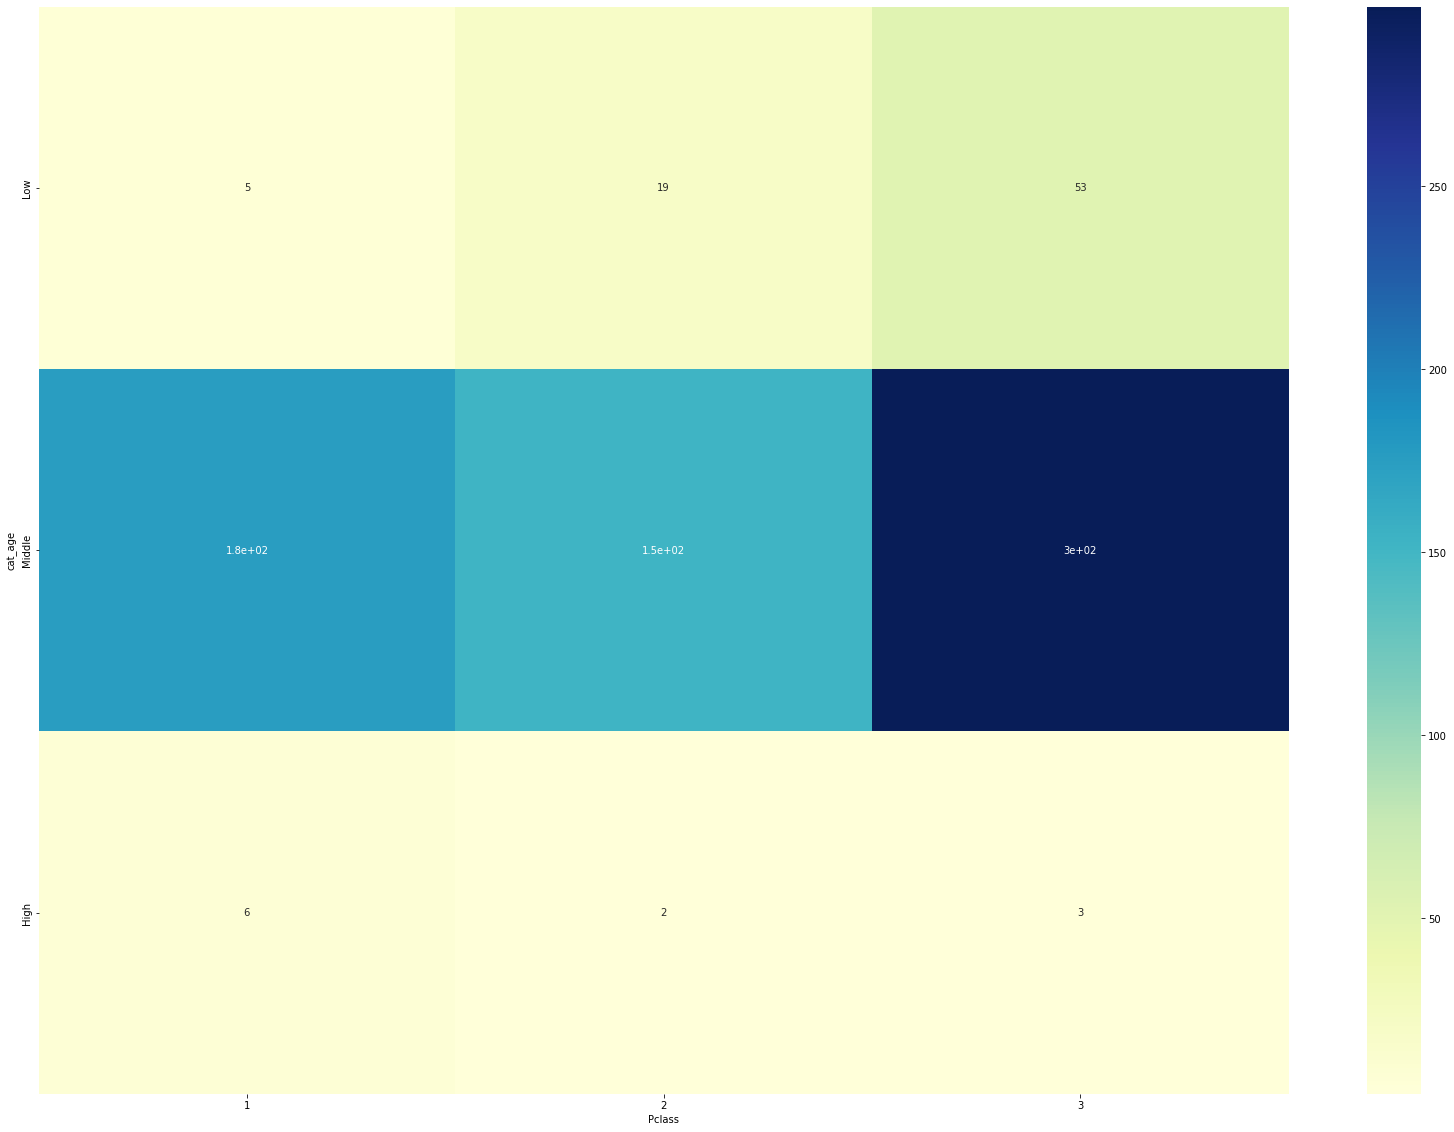

In [19]:
# Age to Pclass
# --- Contingency table
ageToPclassContigencyTable = pd.crosstab(trainingData['cat_age'],trainingData['Pclass'])
# ageToPclassContigencyTable
# # --- Contingency tables in heat map form
matplot.figure(figsize=(28,20))
seaborn.heatmap(ageToPclassContigencyTable, annot=True, cmap="YlGnBu")
# --- Run the Chi-squared test
c, p, dof, expected = chi2_contingency(ageToPclassContigencyTable)
p

<AxesSubplot:>

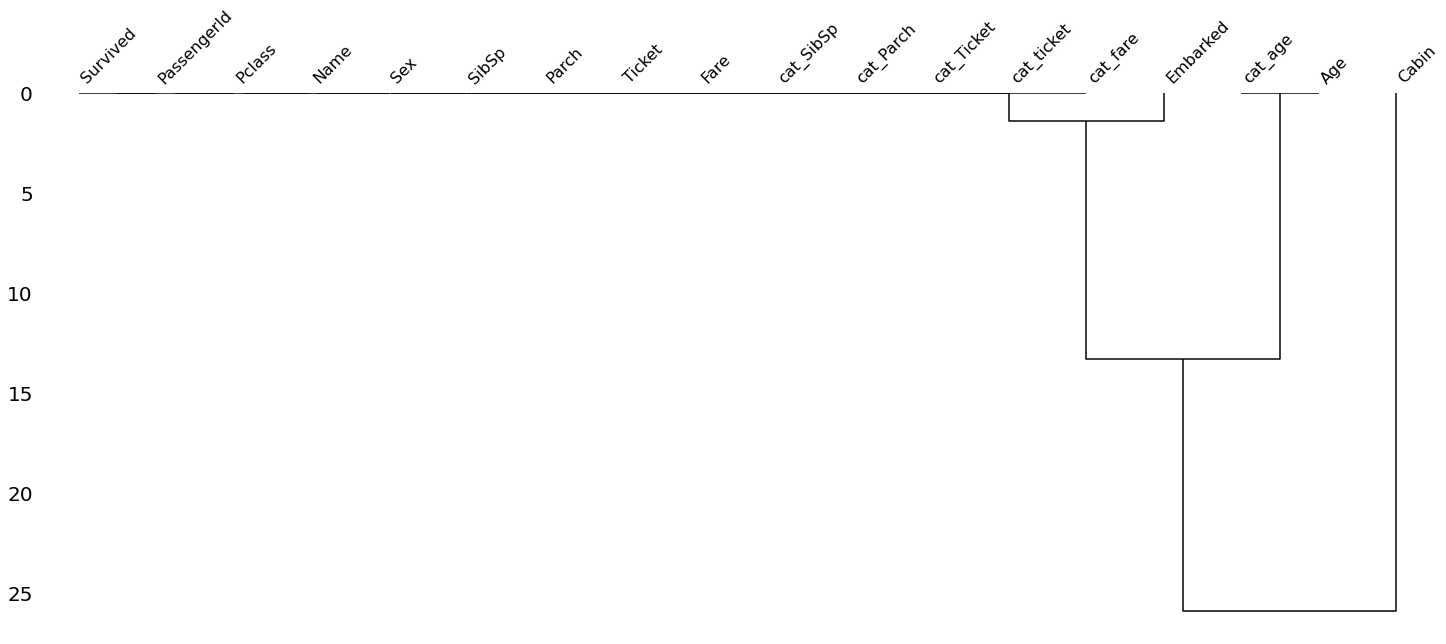

In [20]:
# Draw a dendrogram to visualise the correlations and missingness
misnum.dendrogram(trainingData)

In [21]:
# Impute the 'age' data using the iterative imputer
# The code was adapted from the example in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html
imp = IterativeImputer(max_iter=10, verbose=1, random_state=1)
trainingData['Age'] = imp.fit_transform(trainingData[['Age']])
print(trainingData['Age'])

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64


In [22]:
# Covert the 'embarked' code to numeric data for imputation
# S = 0, C = 1 and Q = 2
new_embarked = []
current_embarked = trainingData['Embarked']
for item in current_embarked:
    if item == 'S':
        new_embarked.append(0)
    elif item == 'C':
        new_embarked.append(1)
    else:
        new_embarked.append(2)
trainingData['Embarked'] = new_embarked

In [23]:
print(trainingData['Embarked'])

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: int64


In [24]:
# Impute the 'embarked' data using the 'mean' imputation method
# This code was adapted from the example code in the documentation https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(trainingData[['Embarked']])
imp.transform(trainingData[['Embarked']])
print(trainingData['Embarked'])

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: int64


In [25]:
# Check for noisy data in the age data
# Trim the dataset down to just the age and into two datasets of male and female, respectively
trainingDataAgeSex = trainingData[['Age','Sex']]
trainingDataMale = trainingDataAgeSex.loc[trainingDataAgeSex['Sex'] == 'male']
trainingDataFemale = trainingDataAgeSex[trainingDataAgeSex['Sex'] == 'female']
# print(trainingDataMale)

In [26]:
# Identify statistical information about the male dataset that was defined above
trainingDataMale.describe()

,Age
count,577.000000
mean,30.505824
std,13.009478
min,0.420000
25%,23.000000
50%,29.699118
75%,35.000000
max,80.000000


In [27]:
# Identify statistical information about the female dataset that was defined above
trainingDataFemale.describe()

,Age
count,314.000000
mean,28.216730
std,12.877543
min,0.750000
25%,21.000000
50%,29.699118
75%,35.000000
max,63.000000


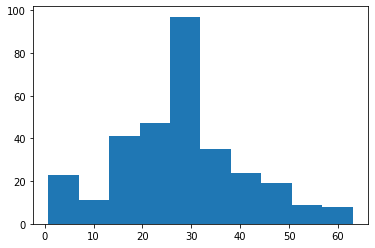

In [28]:
# Draw histograms to identify noisy data in men and women's ages, respectively
# For women:
xAxisFemale = trainingDataFemale['Age']
matplot.hist(xAxisFemale);

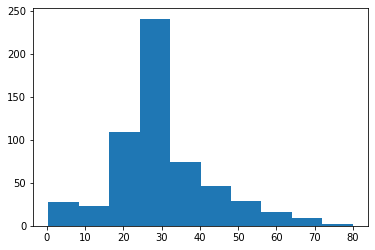

In [29]:
# For men:
xAxisMale = trainingDataMale['Age']
matplot.hist(xAxisMale);

In [30]:
# Count the number of men below 17.628 or above 43.384
print(trainingDataMale[trainingDataMale['Age']<17.628])# those below are 58 in number
print(trainingDataMale[trainingDataMale['Age']>43.384])# those above are 85 in number
print((85+58)/891) # the percentage of men the ages of whom are outliers - 16.1%

       Age   Sex
7     2.00  male
16    2.00  male
50    7.00  male
59   11.00  male
63    4.00  male
78    0.83  male
86   16.00  male
125  12.00  male
138  16.00  male
163  17.00  male
164   1.00  male
165   9.00  male
171   4.00  male
182   9.00  male
183   1.00  male
193   3.00  male
220  16.00  male
261   3.00  male
266  16.00  male
278   7.00  male
282  16.00  male
305   0.92  male
333  16.00  male
340   2.00  male
348   3.00  male
352  15.00  male
386   1.00  male
407   3.00  male
433  17.00  male
445   4.00  male
480   9.00  male
489   9.00  male
500  17.00  male
532  17.00  male
549   8.00  male
550  17.00  male
574  16.00  male
683  14.00  male
686  14.00  male
721  17.00  male
731  11.00  male
746  16.00  male
751   6.00  male
755   0.67  male
764  16.00  male
787   8.00  male
788   1.00  male
791  16.00  male
802  11.00  male
803   0.42  male
819  10.00  male
824   2.00  male
827   1.00  male
831   0.83  male
841  16.00  male
844  17.00  male
850   4.00  male
869   4.00  ma

In [31]:
# Count the number of women below 15.339 or above 41.095
print(trainingDataFemale[trainingDataFemale['Age']<15.339])# those below are 43 in number
print(trainingDataFemale[trainingDataFemale['Age']>41.095])# those above are 48 in number
print((48+43)/891) # the percentage of women the ages of whom are outliers - 10.2%

       Age     Sex
9    14.00  female
10    4.00  female
14   14.00  female
22   15.00  female
24    8.00  female
39   14.00  female
43    3.00  female
58    5.00  female
111  14.50  female
119   2.00  female
147   9.00  female
172   1.00  female
184   4.00  female
205   2.00  female
233   5.00  female
237   8.00  female
297   2.00  female
374   3.00  female
381   1.00  female
419  10.00  female
435  14.00  female
446  13.00  female
448   5.00  female
469   0.75  female
479   2.00  female
530   2.00  female
535   7.00  female
541   9.00  female
542  11.00  female
618   4.00  female
634   9.00  female
642   2.00  female
644   0.75  female
689  15.00  female
691   4.00  female
720   6.00  female
750   4.00  female
777   5.00  female
780  13.00  female
813   6.00  female
830  15.00  female
852   9.00  female
875  15.00  female
      Age     Sex
11   58.0  female
15   55.0  female
52   49.0  female
132  47.0  female
167  45.0  female
177  50.0  female
194  44.0  female
195  58.0  female
25

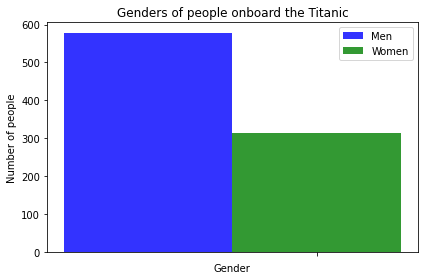

In [32]:
# Show the distribution of men and women on a bar chart
# I used code from here https://pythonspot.com/matplotlib-bar-chart/

# data to plot
noOfWomen = 314
noOfMen = 577
noOfDataSets = 1

# create plot
fig, ax = matplot.subplots()
index = np.arange(noOfDataSets)
bar_width = 0.35
opacity = 0.8

rects1 = matplot.bar(index, noOfMen, bar_width,
alpha=opacity,
color='b',
label='Men')

rects2 = matplot.bar(index + bar_width, noOfWomen, bar_width,
alpha=opacity,
color='g',
label='Women')

matplot.xlabel('Gender')
matplot.ylabel('Number of people')
matplot.title('Genders of people onboard the Titanic')
matplot.xticks(index + bar_width, ())
matplot.legend()

matplot.tight_layout()
matplot.show()

In [33]:
# Calculate a ratio of men and women
print(577/314)

1.8375796178343948


In [34]:
# Calculate the average number of children per woman
over29 = (trainingDataFemale[trainingDataFemale['Age']>29])
noOver29 = 167
noOfChildren = trainingData['Parch'].sum()
print(noOver29)
print(noOfChildren)
print(340/167)

167
340
2.035928143712575


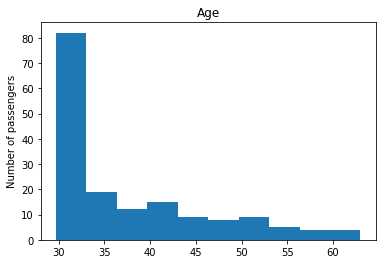

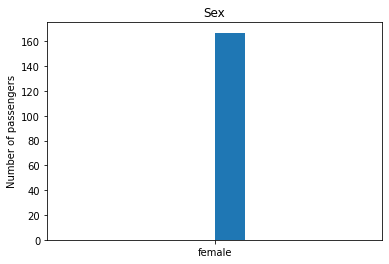

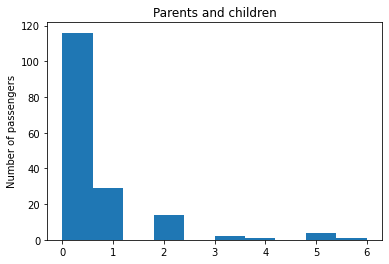

In [35]:
# Check for outliers in the number of children
selectedData = trainingData[['Age','Sex','Parch']]
selectedAge = selectedData[selectedData['Age']>29]
selectedWomen = selectedAge[selectedAge['Sex']=='female']
# Count the number of women children above the S.D (above 3.112)
# print(selectedWomen[selectedWomen['Parch']>3.112])
highOutlier = 6
# Count the number of women children below the S.D (below 1.5)
# print(selectedWomen[selectedWomen['Parch']<1.5])
lowOutlier = 145

totalWomen = 314
totaOutlier = 151
ratio = (151/314)

# Show the women above 29 who have children in a histogram
for iteration in selectedWomen.columns:
    matplot.hist(selectedWomen[iteration])
    if iteration == 'SibSp':
        title = 'Siblings and spouses'
    elif iteration == 'Parch':
        title = 'Parents and children'
    else:
        title = iteration
    matplot.title(title)
    matplot.ylabel('Number of passengers')
    matplot.show()

<AxesSubplot:>

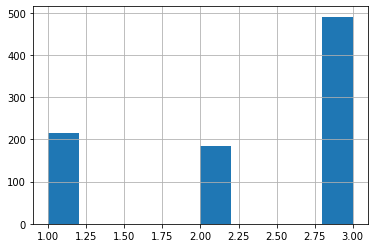

In [36]:
# Draw a bar chart of 'Pclass' to check for noise
trainingData['Pclass'].hist()

In [37]:
trainingData['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [38]:
# Clean out the noisy data of 'SibSp' and replace it with the mean
sibSpMean = 0.523008
trainingData.loc[(trainingData['SibSp']==8) & (trainingData['SibSp']==5)] == 0.523008,0.523008

(Empty DataFrame
 Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked, cat_age, cat_SibSp, cat_Parch, cat_Ticket, cat_ticket, cat_fare]
 Index: [],
 0.523008)

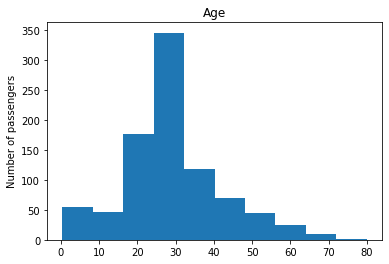

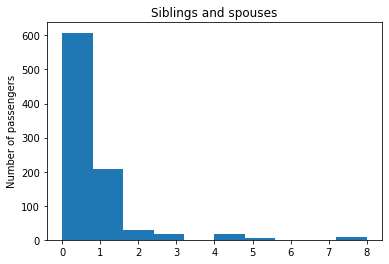

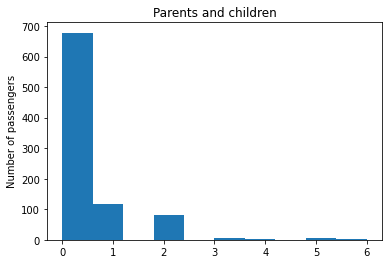

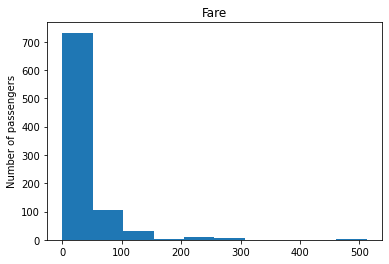

In [39]:
# Show quantitative data in histograms
quanTrainingData = trainingData[['Age','SibSp','Parch','Fare']]
for iteration in quanTrainingData.columns:
    matplot.hist(quanTrainingData[iteration])
    if iteration == 'SibSp':
        title = 'Siblings and spouses'
    elif iteration == 'Parch':
        title = 'Parents and children'
    elif iteration == 'binnedSibsp':
        title = 'Binned Siblings and Spouses'
    else:
        title = iteration
    matplot.title(title)
    matplot.ylabel('Number of passengers')
    matplot.show()

In [40]:
# Check the number of people with no spouses or siblings
peopleOver16 = (trainingData[trainingData.Age > 15])
noOver16 = 800
over16Men = peopleOver16[peopleOver16.Sex == 'male']
noOver16Men = 533
over16Women = peopleOver16[peopleOver16.Sex == 'female']
noOver16Women = 267
over16MarriedOrSpouse = peopleOver16[peopleOver16.SibSp != 0]
noOver16Married =215

<AxesSubplot:>

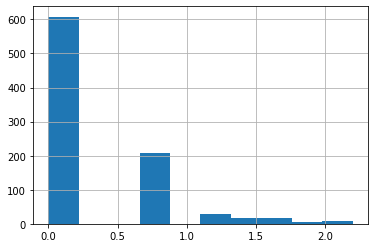

In [41]:
# Log standardise the SibSp
# Backup the non-standardised data
trainingDataSibSp_nonStandard = trainingData['SibSp']
trainingData['norm_SibSp'] = np.log(trainingData.SibSp+1)
trainingData['norm_SibSp'].hist()

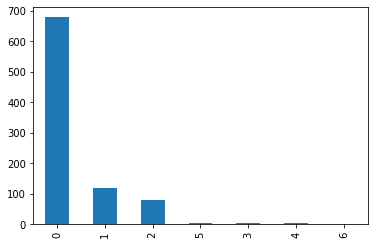

In [42]:
# A bar chart of all of the 'Parch' data to check its distribution
trainingData['Parch'].value_counts().plot(kind='bar');

<AxesSubplot:>

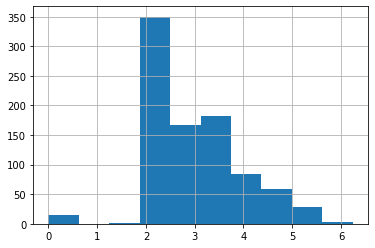

In [43]:
# Log standardise the fare
# Backup the non-standardised data
trainingDataFare_nonStandard = trainingData['Fare']
trainingData['norm_Fare'] = np.log(trainingData.Fare+1)
trainingData['norm_Fare'].hist()

In [44]:
# Standardise all numeric data with the minmax scaler
scale = preprocessing.MinMaxScaler()
all_data_scaled = trainingData.copy()
all_data_scaled[['Age','norm_SibSp','Parch','norm_Fare']]= scale.fit_transform(all_data_scaled[['Age','norm_SibSp','Parch','norm_Fare']])
all_data_scaled

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cat_age,cat_SibSp,cat_Parch,cat_Ticket,cat_ticket,cat_fare,norm_SibSp,norm_Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,0.271174,1,0.000000,A/5 21171,7.2500,NaN,0,Middle,Low,Low,A/5 21171,letter,0-99,0.315465,0.338125
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.472229,1,0.000000,PC 17599,71.2833,C85,1,Middle,Low,Low,PC 17599,letter,0-99,0.315465,0.685892
2,3,1,3,"Heikkinen, Miss. Laina",female,0.321438,0,0.000000,STON/O2. 3101282,7.9250,NaN,0,Middle,Low,Low,STON/O2. 3101282,letter,0-99,0.000000,0.350727
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,1,0.000000,113803,53.1000,C123,0,Middle,Low,Low,113803,noLetter,0-99,0.315465,0.639463
4,5,0,3,"Allen, Mr. William Henry",male,0.434531,0,0.000000,373450,8.0500,NaN,0,Middle,Low,Low,373450,noLetter,0-99,0.000000,0.352955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0.334004,0,0.000000,211536,13.0000,NaN,0,Middle,Low,Low,211536,noLetter,0-99,0.000000,0.422864
887,888,1,1,"Graham, Miss. Margaret Edith",female,0.233476,0,0.000000,112053,30.0000,B42,0,Middle,Low,Low,112053,noLetter,0-99,0.000000,0.550238
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,0.367921,1,0.333333,W./C. 6607,23.4500,NaN,0,NaN,Low,Low,W./C. 6607,letter,0-99,0.315465,0.512205
889,890,1,1,"Behr, Mr. Karl Howell",male,0.321438,0,0.000000,111369,30.0000,C148,1,Middle,Low,Low,111369,noLetter,0-99,0.000000,0.550238


In [45]:
# Create a new column of 'cat_title'
trainingData['Title'] =  trainingData['Name']
all_title_array = ['Lady','Capt','Master','Col','Miss','Major','Mrs','Jonkheer','Mr','Don','Ms','Sir','Mlle','Rev','Mme','Countess','Dona', 'Dr']
title_category_array = []

lady_array = ['Lady']
capt_array = ['Capt']
master_array= ['Master']
col_array = ['Col.']
miss_array = ['Miss']
major_array = ['Major']
mrs_array = ['Mrs']
mr_array = ['Mr']
don_array = ['Don']
ms_array = ['Ms']
sir_array = ['Sir']
mlle_array = ['Mlle']
rev_array = ['Rev']
mme_array = ['Mme']
countess_array = ['countess']
dona_array = ['Dona']
doctor_array = ['Dr']
jonkheer_array = ['Jonkheer']
currentId = 0
# Iterate through the names and extract a title
for item in trainingData['Title'].iteritems():
    currentId = (currentId+1)
    string = str(item)
    if any (title in string for title in all_title_array):
        if any (title in string for title in lady_array):
            title_category_array.append('Lady')
        elif any (title in string for title in capt_array):
            title_category_array.append('Captain')
        elif any (title in string for title in master_array):
            title_category_array.append('Master')
        elif any (title in string for title in col_array):
            title_category_array.append('Colonel')
        elif any (title in string for title in miss_array):
            title_category_array.append('Miss')
        elif any (title in string for title in major_array):
            title_category_array.append('Major')
        elif any (title in string for title in mrs_array):
            title_category_array.append('Mrs.')
        elif any (title in string for title in mr_array):
            title_category_array.append('Mr.')
        elif any (title in string for title in don_array):
            title_category_array.append('Don')
        elif any (title in string for title in ms_array):
            title_category_array.append('Ms.')
        elif any (title in string for title in sir_array):
            title_category_array.append('Sir')
        elif any (title in string for title in rev_array):
            title_category_array.append('Reverend.')
            print(item)
        elif any (title in string for title in mme_array):
            title_category_array.append('Mlle')
        elif any (title in string for title in mme_array):
            title_category_array.append('Mme.')
        elif any (title in string for title in countess_array):
            title_category_array.append('Countess')
        elif any (title in string for title in dona_array):
            title_category_array.append('Dona')
        elif any (title in string for title in doctor_array):
            title_category_array.append('Doctor')
        elif any (title in string for title in jonkheer_array):
            title_category_array.append('Jonkheer')
        else:
            title_category_array.append('N/A')
            print("error in ", item)
    else:
        print(item, "... contains a title not accounted for in the array.")

# Add the title categories to 'cat_title' in the dataframe
# Manually append the titles of 641 and 759 to the array (as these did not parse properly)
title_category_array[641] = 'Mlle'
title_category_array[759] = 'Countess'
trainingData['cat_title'] = title_category_array
pd.set_option('display.max_rows', 900)

(149, 'Byles, Rev. Thomas Roussel Davids')
(150, 'Bateman, Rev. Robert James')
(249, 'Carter, Rev. Ernest Courtenay')
(626, 'Kirkland, Rev. Charles Leonard')
error in  (641, 'Sagesser, Mlle. Emma')
error in  (759, 'Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards)')
(848, 'Harper, Rev. John')
(886, 'Montvila, Rev. Juozas')


In [46]:
# Create a new category of 'rich'
# Ie. Those whose tickets cost more than 200 and are first class
fare_array = trainingData['Fare']
class_array = trainingData['Pclass']
i = 0
rich_array = []
limit = len(class_array)

while i < limit:
    try:
        if (class_array[i] == 1):
            rich_array.append(1)
            i = i + 1
        else:
            rich_array.append(0)
            i = i + 1
    except:
        # Add 'n/a' if whether the passenger is rich or not cannot be determined
        rich_array.append('N/A')
        print("ERROR")
        i = i + 1
# Add the data to the new column
trainingData['cat_rich'] = rich_array
print(trainingData['cat_rich'])

0      0
1      1
2      0
3      1
4      0
5      0
6      1
7      0
8      0
9      0
10     0
11     1
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     1
24     0
25     0
26     0
27     1
28     0
29     0
30     1
31     1
32     0
33     0
34     1
35     1
36     0
37     0
38     0
39     0
40     0
41     0
42     0
43     0
44     0
45     0
46     0
47     0
48     0
49     0
50     0
51     0
52     1
53     0
54     1
55     1
56     0
57     0
58     0
59     0
60     0
61     1
62     1
63     0
64     1
65     0
66     0
67     0
68     0
69     0
70     0
71     0
72     0
73     0
74     0
75     0
76     0
77     0
78     0
79     0
80     0
81     0
82     0
83     1
84     0
85     0
86     0
87     0
88     1
89     0
90     0
91     0
92     1
93     0
94     0
95     0
96     1
97     1
98     0
99     0
100    0
101    0
102    1
103    0
104    0
105    0
106    0
107    0
108    0
109    0
110    1
1

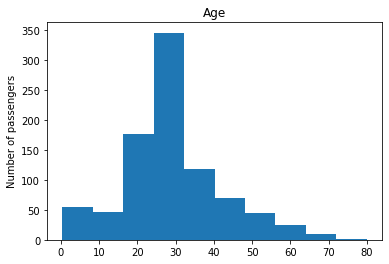

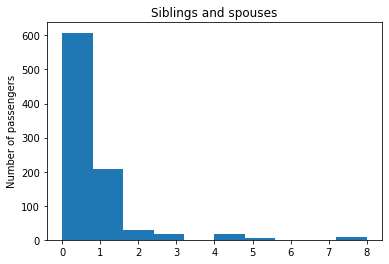

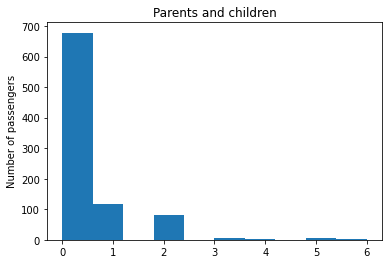

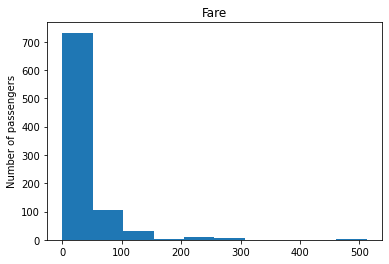

In [47]:
# Draw histograms of the quanitative data
quanTrainingData = trainingData[['Age','SibSp','Parch','Fare']]
for iteration in quanTrainingData.columns:
    matplot.hist(quanTrainingData[iteration])
    if iteration == 'SibSp':
        title = 'Siblings and spouses'
    elif iteration == 'Parch':
        title = 'Parents and children'
    elif iteration == 'binnedSibsp':
        title = 'Binned Siblings and Spouses'
    else:
        title = iteration
    matplot.title(title)
    matplot.ylabel('Number of passengers')
    matplot.show()

In [48]:
# Select those of military age
# Remove those who are clergy
clergy_array = ['Reverend']
to_check_array = []
# Iterate through the names and extract a title
i = 0
for item in trainingData['Title'].iteritems():
    string = str(item)
    if any (title in string for title in clergy_array):
        i = (i + 1)
        to_check_array.append(i)
        print(i)
# Select all men
men_data = trainingData.loc[trainingData['Sex'] == 'male']
# Select those 18 or over
men_data_over_18 = men_data.loc[men_data['Age']>17]
# Remove those over 41
final_military_age_data = men_data_over_18.loc[men_data_over_18['Age']<42]
military_ages_id = final_military_age_data['PassengerId']
in_military_array = []

for item in trainingData['PassengerId']:
    if item in military_ages_id:
        in_military_array.append(1)
    else:
        in_military_array.append(0)
# Assign the categorical data to a new column
trainingData['cat_military'] = in_military_array

In [49]:
# Drop the unneccesary data - the ids, names and tickets
# Backup the data
name_backup = trainingData['Name']
ticket_backup = trainingData['Ticket']
cabin_backup = trainingData['Cabin']
trainingData.drop('Name',axis=1)
trainingData.drop('Ticket',axis=1)
trainingData.drop('Cabin',axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,cat_Parch,cat_Ticket,cat_ticket,cat_fare,norm_SibSp,norm_Fare,Title,cat_title,cat_rich,cat_military
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,...,Low,A/5 21171,letter,0-99,0.693147,2.110213,"Braund, Mr. Owen Harris",Mr.,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,...,Low,PC 17599,letter,0-99,0.693147,4.280593,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs.,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,...,Low,STON/O2. 3101282,letter,0-99,0.000000,2.188856,"Heikkinen, Miss. Laina",Miss,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,...,Low,113803,noLetter,0-99,0.693147,3.990834,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs.,1,1
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,...,Low,373450,noLetter,0-99,0.000000,2.202765,"Allen, Mr. William Henry",Mr.,0,1
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,...,Low,330877,noLetter,0-99,0.000000,2.246893,"Moran, Mr. James",Mr.,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,...,Low,17463,noLetter,0-99,0.000000,3.967694,"McCarthy, Mr. Timothy J",Mr.,1,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,...,Low,349909,noLetter,0-99,1.386294,3.094446,"Palsson, Master. Gosta Leonard",Master,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,...,Low,347742,noLetter,0-99,0.000000,2.495954,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs.,0,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,...,Low,237736,noLetter,0-99,0.693147,3.436268,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs.,0,0


In [50]:
#----START OF ANALYSIS

In [51]:
# Change the 'cat_age' into a format that works with the analysis algorithms ('one hot' encoding)
one_hot_array = []
i = 0
while i < 891:
    one_hot_array.append(0)
    i = (i + 1)
trainingData['0-15'] = one_hot_array
trainingData['16-64'] = one_hot_array
trainingData['65+'] = one_hot_array
iterator = 0
zero_fifteen_array = []
while iterator < 891:
    try:
        currentAge = trainingData['cat_age'].loc[iterator]
        if currentAge == 'Low':
            zero_fifteen_array.append(1)
            iterator = (iterator + 1)
        else:
            zero_fifteen_array.append(0)
            iterator = (iterator + 1)
    except:
        # If there are any errors, put 0 in as default
        zero_fifteen_array.append(0)
        print("Error at ",iterator)
        iterator = (iterator + 1)
trainingData['0-15'] = zero_fifteen_array

iterator = 0
sixteen_sixtyfour_array = []
while iterator < 891:
    try:
        currentAge = trainingData['cat_age'].loc[iterator]
        if currentAge == 'Middle':
            sixteen_sixtyfour_array.append(1)
            iterator = (iterator + 1)
        else:
            sixteen_sixtyfour_array.append(0)
            iterator = (iterator + 1)
    except:
        # If there are any errors, put 0 in as default
        sixteen_sixtyfour_array.append(0)
        #print("Error at ",iterator)
        iterator = (iterator + 1)
trainingData['16-64'] = sixteen_sixtyfour_array

iterator = 0
sixtyfive_array = []
while iterator < 891:
    try:
        currentAge = trainingData['cat_age'].loc[iterator]
        if currentAge == 'High':
            sixtyfive_array.append(1)
            iterator = (iterator + 1)
        else:
            sixtyfive_array.append(0)
            iterator = (iterator + 1)
    except:
        # If there are any errors, put 0 in as default
        sixtyfive_array.append(0)
        #print("Error at ",iterator)
        iterator = (iterator + 1)
trainingData['65+'] = sixteen_sixtyfour_array

In [52]:
# Change the 'sex' into a format that works with the analysis algorithms ('one hot' encoding)
b = 0
gender_array = []
while b < 891:
    currentGender = trainingData['Sex'].loc[b]
    try:
        if currentGender == 'male':
            gender_array.append(0)
            b = (b + 1)
        else:
            gender_array.append(1)
            b = (b + 1)
    except:
        # If there are any errors, put 0 in as default as we need to positively determine if the entry was female or not
        gender_array.append(0)
        b = (b + 1)
        print("Error in ",currentGender)
trainingData['cat_female'] = gender_array

b = 0
gender_array_2 = []
while b < 891:
    currentGender2 = trainingData['Sex'].loc[b]
    try:
        if currentGender2 == 'male':
            gender_array_2.append(1)
            b = (b + 1)
        else:
            gender_array_2.append(0)
            b = (b + 1)
    except:
        # If there are any errors, put 0 in as default as we need to positively determine if the entry was male or not
        gender_array_2.append(0)
        b = (b + 1)
        print("Error in ",currentGender2)
trainingData['cat_male'] = gender_array_2

In [53]:
# Complete a Simple Logistic Regression analysis

Accuracy:  0.6322869955156951


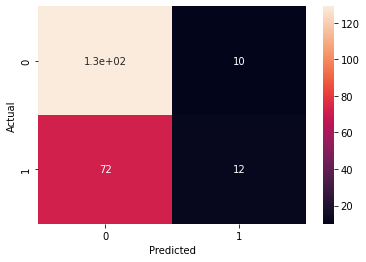

In [54]:
# Being 16 or over to survival
logreg = LogisticRegression()
x = trainingData[['0-15','16-64','65+']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

Accuracy:  0.7802690582959642


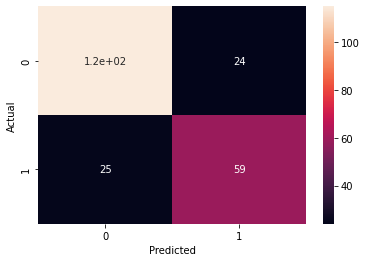

In [55]:
# Being female to survival
logreg = LogisticRegression()
x = trainingData[['cat_female']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

Accuracy:  0.7802690582959642


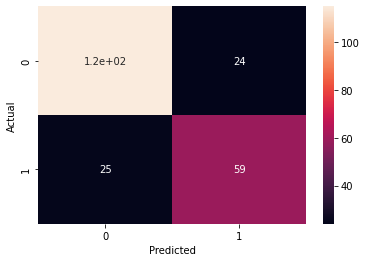

In [56]:
# Being male to survival
logreg = LogisticRegression()
x = trainingData[['cat_male']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

Accuracy:  0.6322869955156951


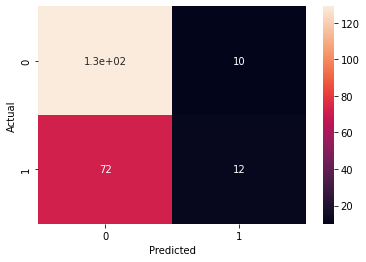

In [57]:
# Being under 16 to survival
logreg = LogisticRegression()
x = trainingData[['0-15']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

Accuracy:  0.7085201793721974


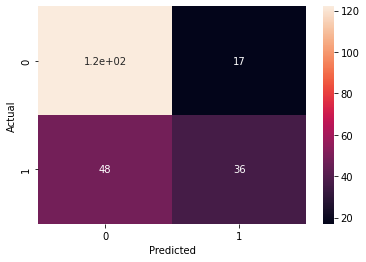

In [58]:
# Being rich to survival
logreg = LogisticRegression()
x = trainingData[['cat_rich']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

Accuracy:  0.6233183856502242


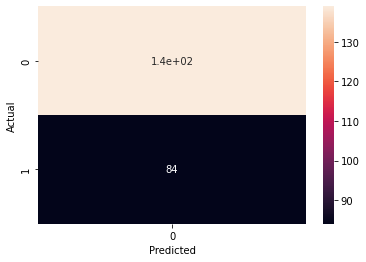

In [59]:
logreg = LogisticRegression()
x = trainingData[['cat_military']]
y = trainingData['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
seaborn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
matplot.show()

In [60]:
# # Complete an Apriori analysis

In [61]:
# Combine the age categories into one column
final_age_array = []
young_age_to_check = trainingData['0-15']
middle_age_to_check = trainingData['16-64']
older_age_to_check = trainingData['65+']
for item in young_age_to_check:
    if item == (1):
        final_age_array.append(1)
    else:
        final_age_array.append(0)
e = 0
for item in middle_age_to_check:
    if item == (1):
        final_age_array[e] = 2
        e = (e + 1)
    else:
        e = (e + 1)
e = 0
for item in older_age_to_check:
    if item == (1):
        final_age_array[e] = 3
        e = (e + 1)
    else:
        e = (e + 1)
# Set the data to a new column, 'cat_all_age'
trainingData['cat_all_age'] = final_age_array

In [62]:
# Add all values from the categorical features to an array (to be added to the dataframe for the apriori algorithm)

to_check_survival = trainingData['Survived']
to_check_rich = trainingData['cat_rich']
to_check_under16 = trainingData['0-15']
to_check_16to64 = trainingData['16-64']
to_check_65plus = trainingData['65+']
to_check_female = trainingData['cat_female']
to_check_male = trainingData['cat_male']
to_check_mil = trainingData['cat_military']

survived_array = []
rich_array = []
under16_array = []
over16_array = []
over65_array = []
female_array = []
male_array = []
mil_array = []
dataframe_index = []
# Add all of the index values to the above array
d = 0
while d < 891:
    dataframe_index.append(d)
    d = (d+1)

# Add survival data
for item in to_check_survival:
    survived_array.append(item)
    
# Add rich data
for item in to_check_rich:
    rich_array.append(item)

# Add under 16 data
for item in to_check_under16:
    under16_array.append(item)

# Add female data
for item in to_check_female:
    female_array.append(item)

# Add male data
for item in to_check_male:
    male_array.append(item)

# Add age data
for item in to_check_16to64:
    over16_array.append(item)
for item in to_check_65plus:
    over65_array.append(item)
    
# Add military data
for item in to_check_mil:
    mil_array.append(item)

# Zip the data so it can be passed to the dataframe
to_add = list(zip(survived_array,rich_array,under16_array,female_array,male_array,over16_array,over65_array,mil_array))

aprioriTrainingData = pd.DataFrame(data = to_add,index=dataframe_index,columns=['Survived','is_rich','under16','female','male','16-64','65+','is_mil'] )
print(aprioriTrainingData)

     Survived  is_rich  under16  female  male  16-64  65+  is_mil
0           0        0        0       0     1      1    1       0
1           1        1        0       1     0      1    1       0
2           1        0        0       1     0      1    1       0
3           1        1        0       1     0      1    1       1
4           0        0        0       0     1      1    1       1
5           0        0        0       0     1      0    0       0
6           0        1        0       0     1      1    1       0
7           0        0        1       0     1      0    0       0
8           1        0        0       1     0      1    1       0
9           1        0        1       1     0      0    0       0
10          1        0        1       1     0      0    0       0
11          1        1        0       1     0      1    1       1
12          0        0        0       0     1      1    1       1
13          0        0        0       0     1      1    1       0
14        

In [63]:
# Apply Apriori
frequent_items = apriori(aprioriTrainingData, min_support=0.0000005, use_colnames=True, verbose=1)
print(frequent_items)

Processing 12 combinations | Sampling itemset size 6
      support                                         itemsets
0    0.383838                                       (Survived)
1    0.242424                                        (is_rich)
2    0.086420                                        (under16)
3    0.352413                                         (female)
4    0.647587                                           (male)
5    0.702581                                          (16-64)
6    0.702581                                            (65+)
7    0.471380                                         (is_mil)
8    0.152637                              (Survived, is_rich)
9    0.050505                              (under16, Survived)
10   0.261504                               (female, Survived)
11   0.122334                                 (male, Survived)
12   0.273850                                (16-64, Survived)
13   0.273850                                  (65+, Survived)
14

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='support', ylabel='support'>

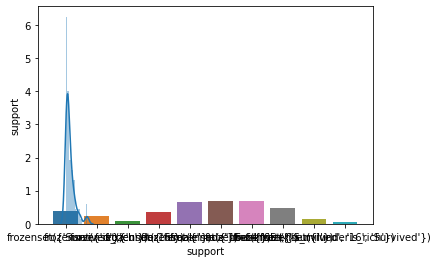

In [64]:
axis = seaborn.barplot(x='itemsets',y='support',data=frequent_items[:10])
seaborn.distplot(frequent_items['support'])

In [65]:
# Mine the association rules
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)
print(rules)

                                    antecedents             consequents  \
0                                     (is_rich)              (Survived)   
1                                     (under16)              (Survived)   
2                                      (female)              (Survived)   
3                                    (Survived)                (female)   
4                                    (Survived)                 (16-64)   
5                                    (Survived)                   (65+)   
6                                     (is_rich)                  (male)   
7                                     (is_rich)                 (16-64)   
8                                     (is_rich)                   (65+)   
9                                     (under16)                  (male)   
10                                     (female)                 (16-64)   
11                                     (female)                   (65+)   
12                       

In [66]:
rules = association_rules(frequent_items, metric="lift", min_threshold=0.5)
print(rules)

     antecedents                              consequents  antecedent support  \
0     (Survived)                                (is_rich)            0.383838   
1      (is_rich)                               (Survived)            0.242424   
2      (under16)                               (Survived)            0.086420   
3     (Survived)                                (under16)            0.383838   
4       (female)                               (Survived)            0.352413   
...          ...                                      ...                 ...   
1083  (Survived)      (65+, male, is_mil, is_rich, 16-64)            0.383838   
1084      (male)  (65+, Survived, is_mil, is_rich, 16-64)            0.647587   
1085    (is_mil)    (65+, Survived, male, is_rich, 16-64)            0.471380   
1086   (is_rich)     (65+, Survived, male, is_mil, 16-64)            0.242424   
1087     (16-64)   (65+, Survived, male, is_mil, is_rich)            0.702581   

      consequent support   

In [67]:
# Print the first 25 rows of the above table
rangeOfRows = 0
while rangeOfRows < 26:
    print(rules.loc[[rangeOfRows]])
    rangeOfRows = (rangeOfRows + 1)

  antecedents consequents  antecedent support  consequent support   support  \
0  (Survived)   (is_rich)            0.383838            0.242424  0.152637   

   confidence      lift  leverage  conviction  
0    0.397661  1.640351  0.059586    1.257723  
  antecedents consequents  antecedent support  consequent support   support  \
1   (is_rich)  (Survived)            0.242424            0.383838  0.152637   

   confidence      lift  leverage  conviction  
1     0.62963  1.640351  0.059586    1.663636  
  antecedents consequents  antecedent support  consequent support   support  \
2   (under16)  (Survived)             0.08642            0.383838  0.050505   

   confidence      lift  leverage  conviction  
2    0.584416  1.522556  0.017334    1.482639  
  antecedents consequents  antecedent support  consequent support   support  \
3  (Survived)   (under16)            0.383838             0.08642  0.050505   

   confidence      lift  leverage  conviction  
3    0.131579  1.522556  0.0

In [68]:
# Sort the table by confidence and print it
sorted_rules = rules.sort_values(by = 'consequent support')
print(sorted_rules.to_string())

                                     antecedents                                 consequents  antecedent support  consequent support   support  confidence      lift  leverage  conviction
512                                     (female)                  (is_mil, under16, is_rich)            0.352413            0.001122  0.001122    0.003185  2.837580  0.000727    1.002069
513                                     (is_mil)                  (female, under16, is_rich)            0.471380            0.002245  0.001122    0.002381  1.060714  0.000064    1.000137
259                                   (Survived)                  (female, under16, is_rich)            0.383838            0.002245  0.001122    0.002924  1.302632  0.000261    1.000681
270                                   (Survived)                    (male, under16, is_rich)            0.383838            0.003367  0.003367    0.008772  2.605263  0.002075    1.005453
258                                     (female)                (

Text(0.5, 1.0, 'Support against confidence')

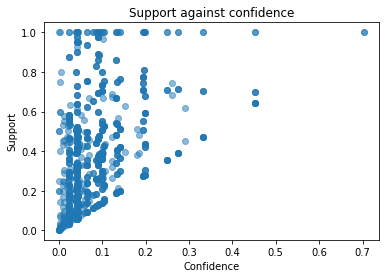

In [69]:
# Plot support vs confidence
matplot.scatter(rules['support'], rules['confidence'], alpha=0.5)
matplot.ylabel('Support')
matplot.xlabel('Confidence')
matplot.title('Support against confidence')

Text(0.5, 1.0, 'Lift against confidence')

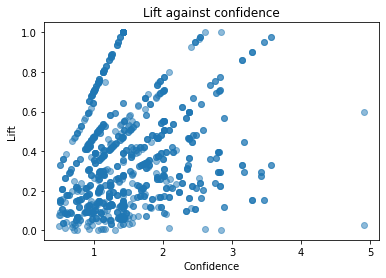

In [70]:
# Plot lift vs confidence
matplot.scatter(rules['lift'], rules['confidence'], alpha=0.5)
matplot.ylabel('Lift')
matplot.xlabel('Confidence')
matplot.title('Lift against confidence')

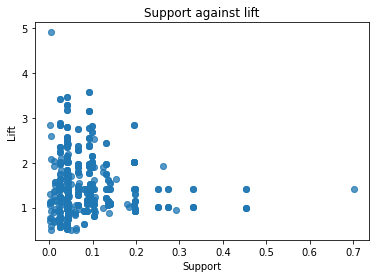

In [71]:
# Plot support against lift
matplot.scatter(rules['support'], rules['lift'], alpha=0.5)
matplot.ylabel('Lift')
matplot.xlabel('Support')
matplot.title('Support against lift')
matplot.show()

In [72]:
# Complete a CatBoost analysis
# X = dependent variable
# Y = survival

In [73]:
# Being rich to survival
X = trainingData[['cat_rich']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.6681614349775785

In [74]:
# Being military to survival
X = trainingData[['cat_military']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.5695067264573991

In [75]:
# Being under 16 to survival
X = trainingData[['0-15']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.600896860986547

In [76]:
# Age in general to survival
X = trainingData[['cat_all_age']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.600896860986547

In [77]:
# Being female to survival
X = trainingData[['cat_female']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.7623318385650224

In [78]:
# Being male to survival
X = trainingData[['cat_male']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

catboost = CatBoostClassifier(verbose=0) 
catboost.fit(X_train, y_train)
y_pred = catboost.predict(X_test)
accuracy_score(y_test, y_pred)

0.7623318385650224

In [79]:
# Complete a random forest model

In [80]:
# On being female to survival
# Split the data into a training and testing split using an 75:25 ratio
X = trainingData[['cat_female']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [81]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       127
           1       0.77      0.64      0.70        96

    accuracy                           0.76       223
   macro avg       0.76      0.75      0.75       223
weighted avg       0.76      0.76      0.76       223



In [82]:
print(cm(y_test,prediction))

[[109  18]
 [ 35  61]]


In [83]:
# On being male to survival
X = trainingData[['cat_male']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [84]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       127
           1       0.77      0.64      0.70        96

    accuracy                           0.76       223
   macro avg       0.76      0.75      0.75       223
weighted avg       0.76      0.76      0.76       223



In [85]:
print(cm(y_test,prediction))

[[109  18]
 [ 35  61]]


In [86]:
# On being of military age to survival
# Split the data into a training and testing split using an 75:25 ratio
X = trainingData[['cat_military']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [87]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.57      1.00      0.73       127
           1       0.00      0.00      0.00        96

    accuracy                           0.57       223
   macro avg       0.28      0.50      0.36       223
weighted avg       0.32      0.57      0.41       223



/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [88]:
print(cm(y_test,prediction))

[[127   0]
 [ 96   0]]


In [89]:
# On being rich to survival
# Split the data into a training and testing split using an 75:25 ratio
X = trainingData[['cat_rich']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [90]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.66      0.85      0.74       127
           1       0.68      0.43      0.53        96

    accuracy                           0.67       223
   macro avg       0.67      0.64      0.64       223
weighted avg       0.67      0.67      0.65       223



In [91]:
print(cm(y_test,prediction))

[[108  19]
 [ 55  41]]


In [92]:
# On being under 16 to survival
# Split the data into a training and testing split using an 75:25 ratio
X = trainingData[['0-15']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [93]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.59      0.96      0.73       127
           1       0.71      0.12      0.21        96

    accuracy                           0.60       223
   macro avg       0.65      0.54      0.47       223
weighted avg       0.64      0.60      0.51       223



In [94]:
print(cm(y_test,prediction))

[[122   5]
 [ 84  12]]


In [95]:
# On age in general to survival
# Split the data into a training and testing split using an 75:25 ratio
X = trainingData[['cat_all_age']]
y = trainingData['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
classifier = rfc(n_estimators=600)
classifier.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

In [96]:
prediction = classifier.predict(X_test)
print(cr(y_test, prediction))

              precision    recall  f1-score   support

           0       0.59      0.96      0.73       127
           1       0.71      0.12      0.21        96

    accuracy                           0.60       223
   macro avg       0.65      0.54      0.47       223
weighted avg       0.64      0.60      0.51       223



In [97]:
print(cm(y_test,prediction))

[[122   5]
 [ 84  12]]
